# Task B: Image Super-Resolution

Gravitational lensing has been a cornerstone in many cosmology experiments and studies since it was discussed in Einstein’s calculations back in 1936 and discovered in 1979, and one area of particular interest is the study of dark matter via substructure in strong lensing images. In this challenge, we focus on exploring the potential of ML models in enhancing the resolution of lensing images.

In this task, we will develop and train a super-resolution model to enhance the quality of low-resolution strong gravitational lensing images. The goal is to upscale noisy and blurry images to higher resolutions, improving their clarity and detail. Participants can explore different super-resolution techniques, including convolutional neural networks (CNNs), generative adversarial networks (GANs), and other deep learning approaches.

![HR and LR Image Pair](https://github.com/ML4SCI/DeepLearnHackathon/blob/main/GravitationalLensingChallenge/hr_lr_pair.png?raw=true)

This is an example notebook for the Image Super-Resolution Challenge. In this notebook, we demonstrate a simple CNN model implemented using the PyTorch library to solve the task of super-resolution of strong lensing images.

### Dataset

The Dataset consists of high-resolution (HR) and low-resolution (LR) pairs. The images have been normalized using min-max normalization.

Link to the Dataset: https://drive.google.com/file/d/1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld/view?usp=sharing

### Evaluation Metrics

* MSE (Mean Squared error), SSIM (Similarity Index), and PSNR (Signal to Noise Ratio)   

The model performance will be tested on the hidden test dataset based on the above metrics. More details about these metrics and the code to calculate them has been shared below.

### Instructions for using the notebook

1. Use GPU acceleration: (Edit --> Notebook settings --> Hardware accelerator --> GPU)
2. Run the cells: (Runtime --> Run all)

In [1]:
!pip install gdown

In [2]:
import gdown

In [3]:
import os
# Check if the dataset folder is missing
if not os.path.exists('./dataset_superres'):
    # Download and extract the dataset
    !gdown "http://drive.google.com/uc?id=1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld"
    !unzip -q dataset.zip
    !mv dataset dataset_superres

Downloading...
From (original): http://drive.google.com/uc?id=1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld
From (redirected): https://drive.google.com/uc?id=1yJBvKD4saonRfSy4r0ceuD9qzgrdrHld&confirm=t&uuid=3cf11c46-4976-4d9d-9440-1d11221e1369
To: /content/dataset.zip
100% 1.83G/1.83G [00:23<00:00, 77.3MB/s]


## Single Image Super Resolution

### 1. Data Visualization and Preprocessing

#### 1.1 Import all the necessary libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import Variable
from tqdm.notebook import tqdm
import torch.utils.data as data
import torch.nn.functional as F
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
%matplotlib inline

#### 1.2 Preview the Data

High-Resolution (HR) samples: 


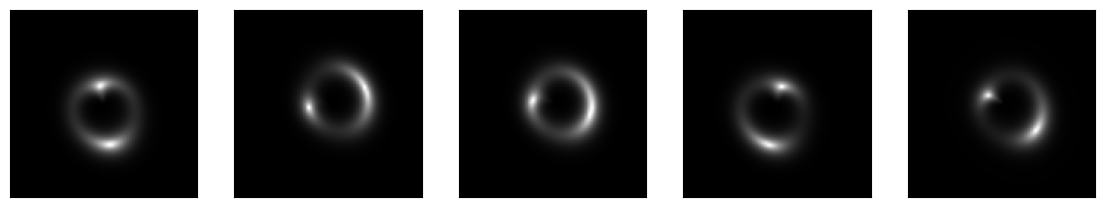

Low-Resolution (LR) samples: 


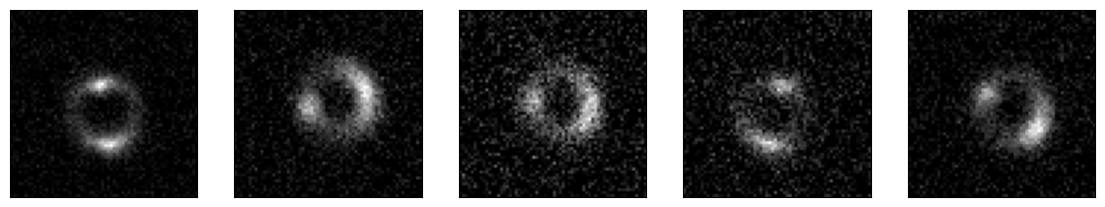

In [5]:
# Define the input paths for high-resolution (HR) and low-resolution (LR) training images
train_hr_path = './dataset_superres/train/HR'
train_hr_files = [os.path.join(train_hr_path, f) for f in os.listdir(train_hr_path) if f.endswith(".npy")]
train_lr_path = './dataset_superres/train/LR'
train_lr_files = [os.path.join(train_lr_path, f) for f in os.listdir(train_lr_path) if f.endswith(".npy")]

# Number of samples to display
n = 5

# Plot the high-resolution (HR) samples
i = 1
print('High-Resolution (HR) samples: ')
plt.rcParams['figure.figsize'] = [14, 14]
for image in train_hr_files[:n]:  # Loop through the first n HR images
    ax = plt.subplot(2, n, i)  # Create subplot for the current image
    plt.imshow(np.load(image).reshape(128,128), cmap='gray')  # Load and display the image in grayscale
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1  # Increment the subplot index
plt.show()  # Display the plot

# Plot the low-resolution (LR) samples
print('Low-Resolution (LR) samples: ')
plt.rcParams['figure.figsize'] = [14, 14]
for image in train_lr_files[:n]:  # Loop through the first n LR images
    ax = plt.subplot(2, n, i)  # Create subplot for the current image
    plt.imshow(np.load(image).reshape(64,64), cmap='gray')  # Load and display the image in grayscale
    ax.get_xaxis().set_visible(False)  # Hide x-axis
    ax.get_yaxis().set_visible(False)  # Hide y-axis
    i += 1  # Increment the subplot index
plt.show()  # Display the plot

In [6]:
# Get number of training images
num_train_images = len(train_hr_files)
print(f"Number of training images: {num_train_images}")
sample_hr_image = np.load(train_hr_files[0])
sample_lr_image = np.load(train_lr_files[0])
print(sample_hr_image.shape)
print(sample_lr_image.shape)

Number of training images: 10000
(1, 128, 128)
(1, 64, 64)
